<a href="https://colab.research.google.com/github/Geeta-Santhosh/My-Teableau-learning/blob/main/kaggle_churn_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Geeta-New-Drive/kaggle data set/Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
data.shape

(10000, 14)

In [ ]:
data['Exited'].unique()

array([1, 0])

In [ ]:
#maping 0 and 1 to exited and stayed employees
data['Exited'] = data['Exited'].map({0 : 'Stay', 1 : 'Exited'})

In [ ]:
#Exited and stayed in percentage
exited_proportion = data['Exited'].value_counts(normalize=True)*100
exited_proportion

,proportion
Exited,
Stay,79.63
Exited,20.37


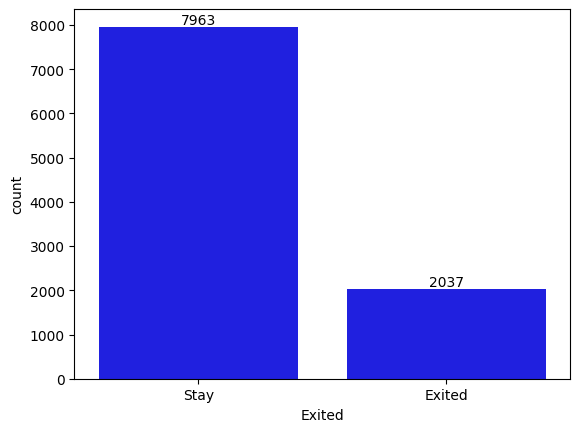

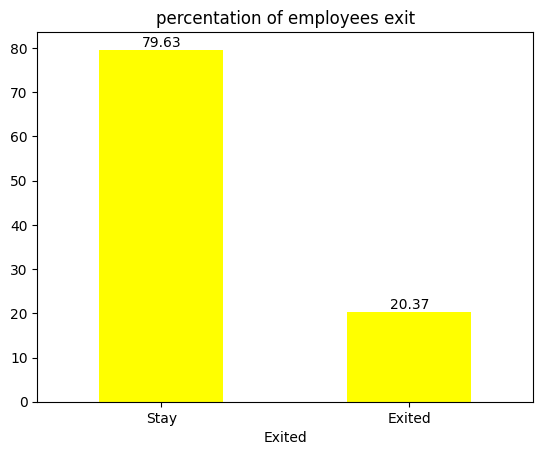

In [ ]:
ax = sns.countplot(x=data['Exited'], order=data['Exited'].value_counts().index, color='blue')
ax.bar_label(ax.containers[0])
plt.title('count of employees exit')
plt.show()


ax = exited_proportion.plot.bar(color='yellow')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.title('percentation of employees exit')
plt.show()

In [ ]:
data['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
# Geographycally exited status in percentage
geography_exited = round(data.groupby('Geography')['Exited'].value_counts(normalize=True)*100,2)
geography_exited

Geography  Exited
France     Stay      83.85
           Exited    16.15
Germany    Stay      67.56
           Exited    32.44
Spain      Stay      83.33
           Exited    16.67
Name: proportion, dtype: float64

min:  18
max:  92
q1:  32.0
q2:  37.0
q3:  44.0
Lower fence is:  14.0
upper fence is:  62.0


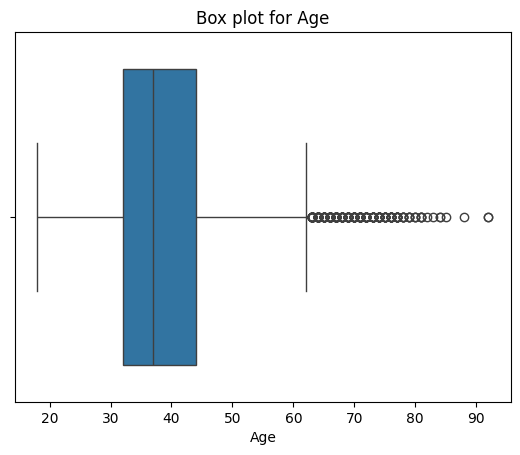

In [ ]:
#Boxplot for Geographycal outliers

min = data['Age'].min()
max = data['Age'].max()
q1 = data['Age'].quantile(0.25)
q2 = data['Age'].quantile(0.5)
q3 = data['Age'].quantile(0.75)

print('min: ', min)
print('max: ', max)
print('q1: ', q1)
print('q2: ', q2)
print('q3: ', q3)

iqr = q3 - q1

lower_fence = q1 - 1.5*(iqr)
upper_fence = q3 + 1.5*(iqr)

print('Lower fence is: ', lower_fence)
print('upper fence is: ', upper_fence)

sns.boxplot(x=data['Age'])
plt.title('Box plot for Age')
plt.show()

In [ ]:
# finding where the outliers are lieaing
data['Age'].describe(percentiles=[0.25,0.5,0.75,0.8,0.85,0.9,0.95,0.98])

,Age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
80%,46.000000
85%,49.000000
90%,53.000000


In [ ]:

data['IsActiveMember'].value_counts()

,count
IsActiveMember,
1,5151
0,4849


In [ ]:
data_proportion= data['Gender'].value_counts(normalize=True)*100
data_proportion

,proportion
Gender,
Male,54.57
Female,45.43


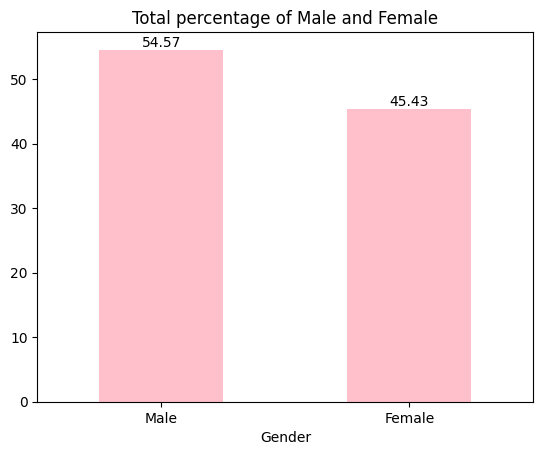

In [ ]:
ax = data_proportion.plot.bar(color='pink')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.title('Total percentage of Male and Female')
plt.show()

In [ ]:
grouped=round(data.groupby('Gender')['Exited'].value_counts(normalize=True)*100,2)

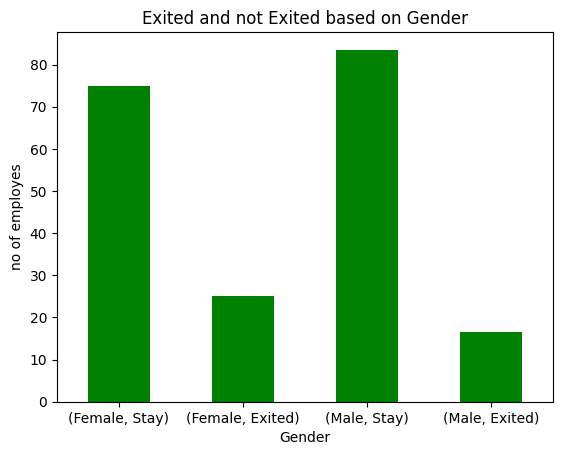

In [ ]:
grouped.plot(kind='bar', color = 'Green')
plt.title('Exited and not Exited based on Gender')
plt.xlabel('Gender')
plt.ylabel('no of employes')
plt.xticks(rotation=0)
plt.show()


In [ ]:
data.groupby('Age')['Exited'].size()

,Exited
Age,
18,22
19,27
20,40
21,53
22,84
...,...
83,1
84,2
85,1
